In [1]:
import snntorch as nn
from snntorch import utils
import torch
from torch.utils.data import DataLoader

import torchvision
from torchvision import datasets, transforms

In [2]:
transform = transforms.Compose([
    transforms.Resize((28,28)),
    transforms.Grayscale(),
    transforms.ToTensor(),
    transforms.Normalize((0,),(1,))]

)

In [3]:
train_dataset = torchvision.datasets.MNIST(
    root="./data",
    download= True,
    train = True,
    transform = transform
)

In [4]:
subset = 10
mnist_train = utils.data_subset(train_dataset,subset)

In [5]:
len(mnist_train)

6000

In [6]:
batch_size=128
train_loader =DataLoader(
    mnist_train,
    batch_size = batch_size,
    shuffle =True
)

## Rate (Bernoulli) Encoding

In [7]:
num_steps = 100

raw_vector = torch.ones(num_steps)*0.5

rate_coded_vector = torch.bernoulli(raw_vector)

In [8]:
rate_coded_vector

tensor([1., 1., 0., 1., 1., 0., 0., 0., 1., 1., 0., 0., 0., 1., 1., 0., 1., 0.,
        0., 0., 1., 0., 0., 0., 1., 1., 1., 0., 1., 0., 0., 1., 0., 1., 1., 0.,
        1., 0., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 1., 1., 0., 0., 1.,
        1., 0., 1., 1., 1., 0., 1., 1., 1., 1., 0., 0., 0., 1., 0., 0., 0., 0.,
        1., 0., 1., 0., 1., 0., 0., 1., 1., 0., 1., 0., 1., 1., 1., 0., 0., 0.,
        0., 0., 0., 0., 1., 1., 1., 1., 1., 0.])

In [9]:
rate_coded_vector.sum()*100/len(rate_coded_vector)

tensor(51.)

As num_steps →∞, the proportion of spikes approaches the original raw value.

In [10]:
from snntorch import spikegen

data= iter(train_loader)
data_it, target_it = next(data)

spike_data = spikegen.rate(data_it,num_steps=num_steps)

The structure of the input data is [num_steps x batch_size x input dimensions]:

In [11]:
print(spike_data.size())

torch.Size([100, 128, 1, 28, 28])


## Visualization

In [12]:
import matplotlib.pyplot as plt
import snntorch.spikeplot as splt 
from IPython.display import HTML

In [13]:
spike_data_sample = spike_data[:,0,0]
print(spike_data_sample.size())

torch.Size([100, 28, 28])


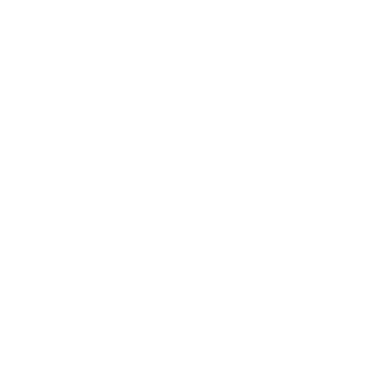

In [17]:
fig,ax =plt.subplots()
anim = splt.animator(spike_data_sample,fig,ax)

HTML(anim.to_jshtml())

In [18]:
anim.save("spike_mnist_test.mp4")

In [20]:
target_it[0]

tensor(5)

### Lets do the same thing with less gain

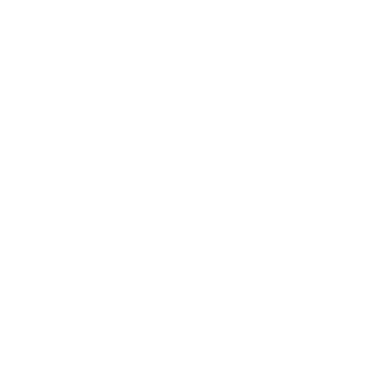

In [21]:
spike_data = spikegen.rate(data_it, num_steps=num_steps, gain=0.25)

spike_data_sample2 = spike_data[:, 0, 0]
fig, ax = plt.subplots()
anim = splt.animator(spike_data_sample2, fig, ax)
HTML(anim.to_html5_video())


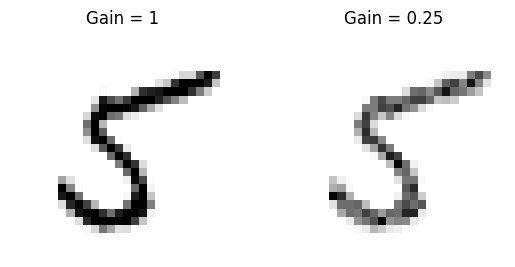

In [22]:
plt.figure(facecolor="w")
plt.subplot(1,2,1)
plt.imshow(spike_data_sample.mean(axis=0).reshape((28,-1)).cpu(), cmap='binary')
plt.axis('off')
plt.title('Gain = 1')

plt.subplot(1,2,2)
plt.imshow(spike_data_sample2.mean(axis=0).reshape((28,-1)).cpu(), cmap='binary')
plt.axis('off')
plt.title('Gain = 0.25')

plt.show()